<a href="https://colab.research.google.com/github/rahmani3101/Data-Science-and-Machine-Learning/blob/main/Netflix_Title_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/netflix_titles.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Cleaning: Handling Missing Values and Data Types



In [2]:
print('Missing values per column:')
print(df.isnull().sum())

print('\nData types per column:')
print(df.dtypes)

Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Data types per column:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [22]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

print("Missing values after filling 'director', 'cast', 'country':")
print(df.isnull().sum())

Missing values after filling 'director', 'cast', 'country':
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
dtype: int64


/tmp/ipykernel_5465/3006692311.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_5465/3006692311.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [23]:
#  Useing  errors='coerce' to turn unparseable dates into NaT (Not a Time).
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [24]:
mode_date = df['date_added'].mode()[0]
df['date_added'] = df['date_added'].fillna(mode_date)

In [25]:
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
dtype: int64


### Handling Duration and Rating

In [26]:
# Separating movies and TV shows for duration parsing
movies_df = df[df['type'] == 'Movie'].copy()
tvshows_df = df[df['type'] == 'TV Show'].copy()

In [28]:
# Converting 'duration' for movies (e.g., '90 min' to 90)
# Convert the 'duration' column to string type to ensure .str accessor works correctly
movies_df['duration'] = movies_df['duration'].astype(str).str.replace(' min', '', regex=False)
movies_df['duration'] = pd.to_numeric(movies_df['duration'], errors='coerce')

In [30]:
# Convert 'duration' for TV shows (e.g., '2 Seasons' to 2)
tvshows_df['duration'] = tvshows_df['duration'].astype(str).str.replace(' Seasons?', '', regex=True) # Changed regex=False to regex=True
tvshows_df['duration'] = pd.to_numeric(tvshows_df['duration'], errors='coerce')

In [31]:
# Fill missing duration values with mean for movies and mode for TV shows
movies_df['duration'] = movies_df['duration'].fillna(movies_df['duration'].mean())
tvshows_df['duration'] = tvshows_df['duration'].fillna(tvshows_df['duration'].mode()[0]) # Changed inplace=True


In [32]:
df = pd.concat([movies_df, tvshows_df])

In [33]:
# Fill missing 'rating' values with the mode
mode_rating = df['rating'].mode()[0]
df['rating'] = df['rating'].fillna(mode_rating)

In [34]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


### Handling Duplicate Entries

In [35]:
# Check for duplicate entries
duplicates = df.duplicated().sum()
print(f"Number of duplicate entries: {duplicates}")

Number of duplicate entries: 0


In [37]:
df.shape

(8807, 13)

### Outlier Detection

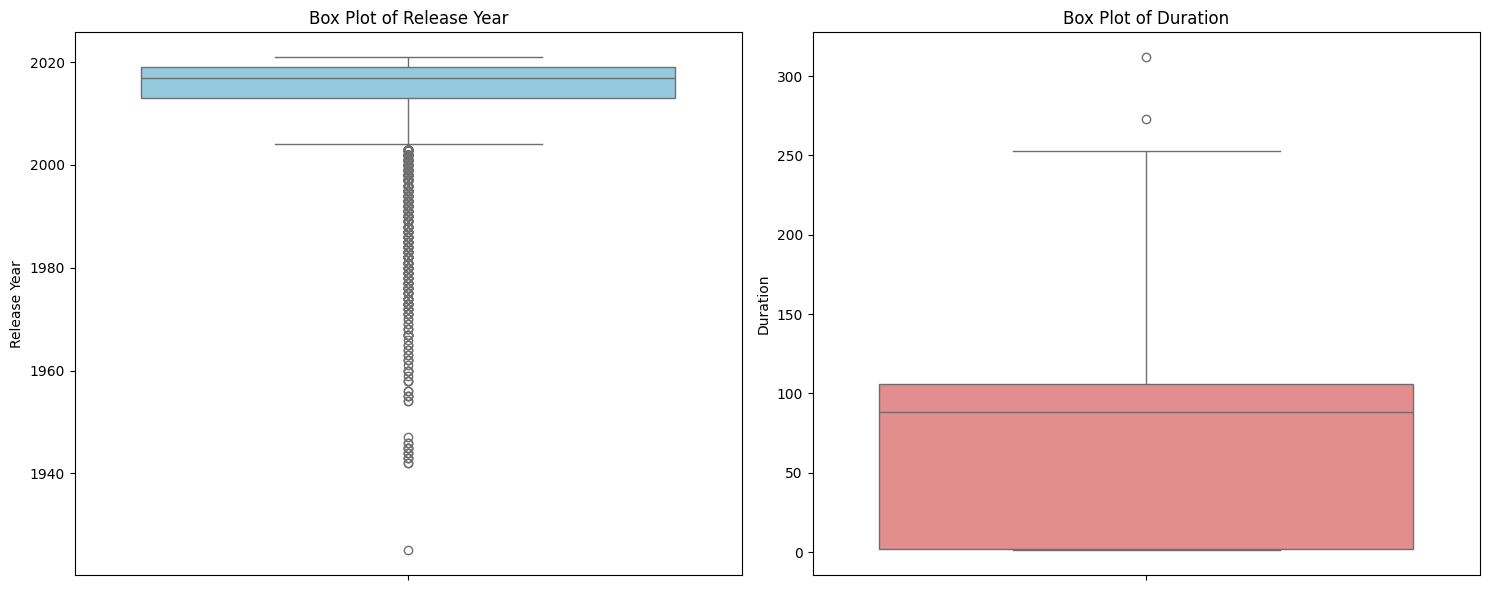

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(ax=axes[0], y=df['release_year'], color='skyblue')
axes[0].set_title('Box Plot of Release Year')
axes[0].set_ylabel('Release Year')

sns.boxplot(ax=axes[1], y=df['duration'], color='lightcoral')
axes[1].set_title('Box Plot of Duration')
axes[1].set_ylabel('Duration')

plt.tight_layout()
plt.show()

In [40]:
print("Description of 'release_year':")
display(df['release_year'].describe())

Description of 'release_year':


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [41]:
print("\nDescription of 'duration':")
display(df['duration'].describe())


Description of 'duration':


,duration
count,8807.000000
mean,69.857015
std,50.809134
min,1.000000
25%,2.000000
50%,88.000000
75%,106.000000
max,312.000000


### Separate Outlier Analysis for Duration (Movies vs. TV Shows)


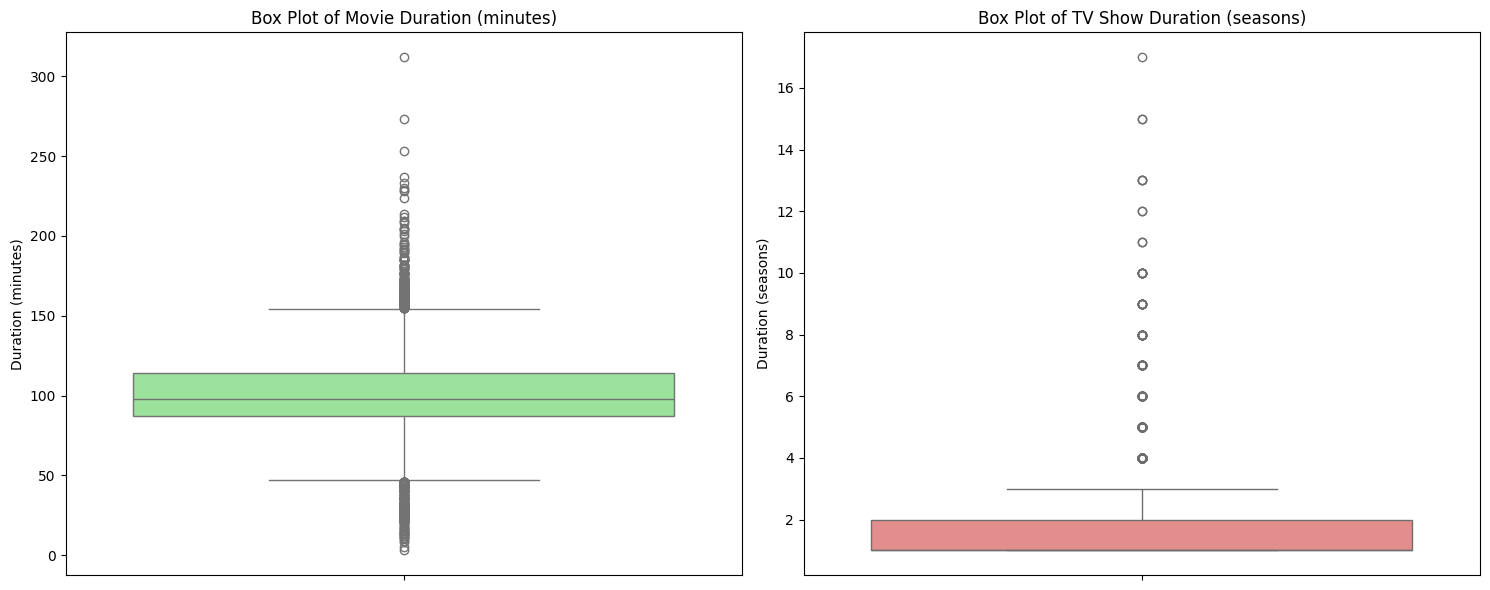

In [42]:
# Separate movies and TV shows again (ensure we are working with the latest df)
movies_df_outliers = df[df['type'] == 'Movie'].copy()
tvshows_df_outliers = df[df['type'] == 'TV Show'].copy()

# Set up the matplotlib figure and axes for subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot for 'duration' in movies
sns.boxplot(ax=axes[0], y=movies_df_outliers['duration'], color='lightgreen')
axes[0].set_title('Box Plot of Movie Duration (minutes)')
axes[0].set_ylabel('Duration (minutes)')

# Box plot for 'duration' in TV shows
sns.boxplot(ax=axes[1], y=tvshows_df_outliers['duration'], color='lightcoral')
axes[1].set_title('Box Plot of TV Show Duration (seasons)')
axes[1].set_ylabel('Duration (seasons)')

plt.tight_layout()
plt.show()

In [43]:
display(movies_df_outliers['duration'].describe())

,duration
count,6131.000000
mean,99.577187
std,28.283670
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


In [44]:
print("\nDescription of 'duration' for TV Shows:")
display(tvshows_df_outliers['duration'].describe())


Description of 'duration' for TV Shows:


,duration
count,2676.000000
mean,1.764948
std,1.582752
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,17.000000


## Univariate Analysis

### Distribution of Content Type (Movie vs. TV Show)

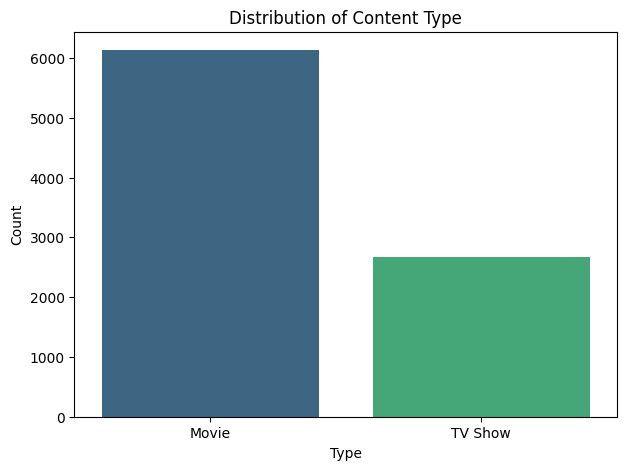

In [45]:
plt.figure(figsize=(7, 5))
sns.countplot(x='type', data=df, palette='viridis', hue='type', legend=False)
plt.title('Distribution of Content Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

In [46]:
print("Count of Movies and TV Shows:")
display(df['type'].value_counts())

Count of Movies and TV Shows:


,count
type,
Movie,6131
TV Show,2676


### Distribution of Content Rating

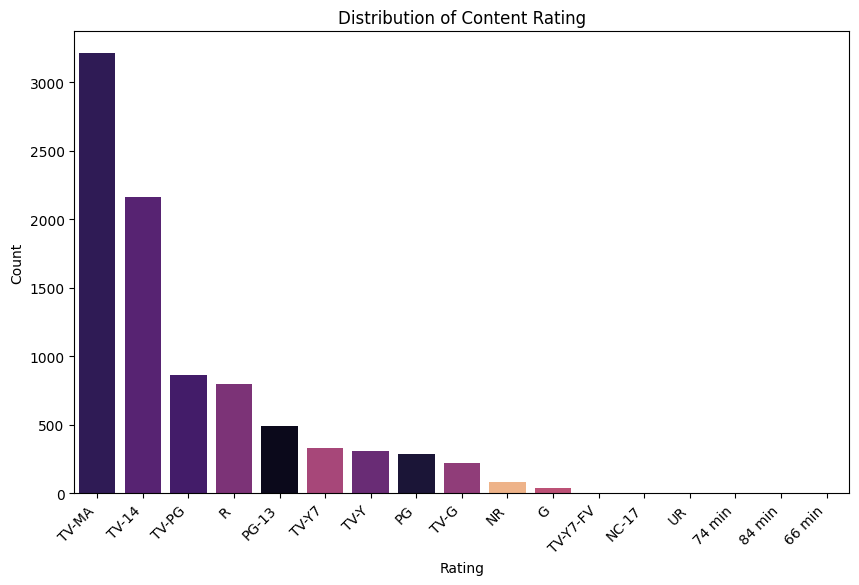

In [47]:
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=df, palette='magma', order=df['rating'].value_counts().index, hue='rating', legend=False)
plt.title('Distribution of Content Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

In [48]:
print("Count of Each Rating:")
display(df['rating'].value_counts())

Count of Each Rating:


,count
rating,
TV-MA,3211
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


### Distribution of Release Year

/tmp/ipykernel_5465/2966626522.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['release_year'], bins=30, kde=True, palette='coolwarm')


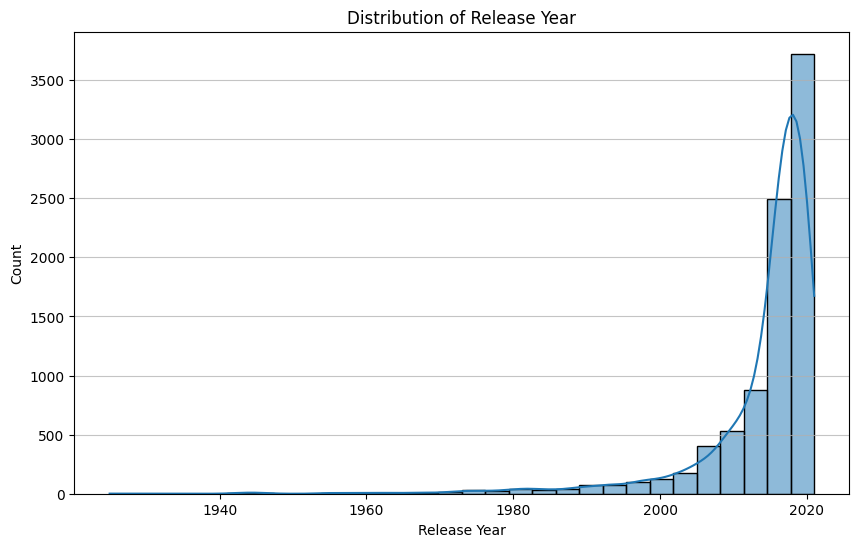

In [49]:
plt.figure(figsize=(10, 6))
sns.histplot(df['release_year'], bins=30, kde=True, palette='coolwarm')
plt.title('Distribution of Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [50]:
print("Descriptive Statistics for Release Year:")
display(df['release_year'].describe())

Descriptive Statistics for Release Year:


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


### Distribution of Date Added

/tmp/ipykernel_5465/757946157.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['year_added'], bins=15, kde=True, palette='coolwarm')


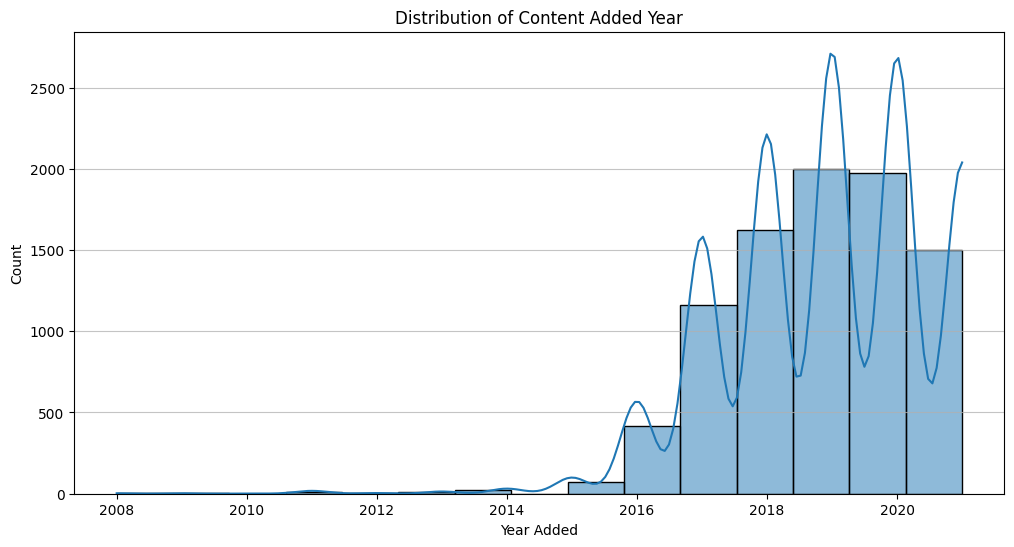

In [51]:
plt.figure(figsize=(12, 6))
df['year_added'] = df['date_added'].dt.year
sns.histplot(df['year_added'], bins=15, kde=True, palette='coolwarm')
plt.title('Distribution of Content Added Year')
plt.xlabel('Year Added')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [52]:
print("Descriptive Statistics for Year Added:")
display(df['year_added'].describe())

Descriptive Statistics for Year Added:


,year_added
count,8807.000000
mean,2018.900307
std,1.563570
min,2008.000000
25%,2018.000000
50%,2019.000000
75%,2020.000000
max,2021.000000


### Distribution of Content by Country

In [53]:
countries = df['country'].str.split(', ', expand=True).stack()

/tmp/ipykernel_5465/1090010940.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=countries.value_counts().index[:10], x=countries.value_counts().head(10), palette='viridis')


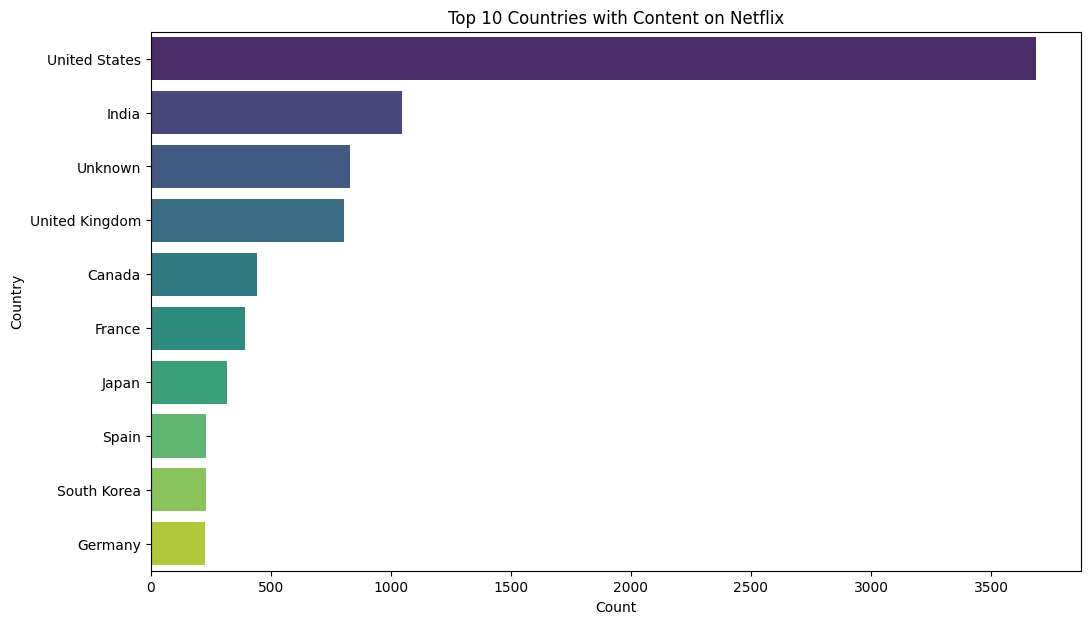

In [54]:
plt.figure(figsize=(12, 7))
sns.barplot(y=countries.value_counts().index[:10], x=countries.value_counts().head(10), palette='viridis')
plt.title('Top 10 Countries with Content on Netflix')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

In [55]:
print("Top 10 Countries with Content:")
display(countries.value_counts().head(10))

Top 10 Countries with Content:


,count
United States,3689
India,1046
Unknown,831
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


## Bivariate Analysis: Exploring Relationships Between Variables

### Content Type vs. Release Year

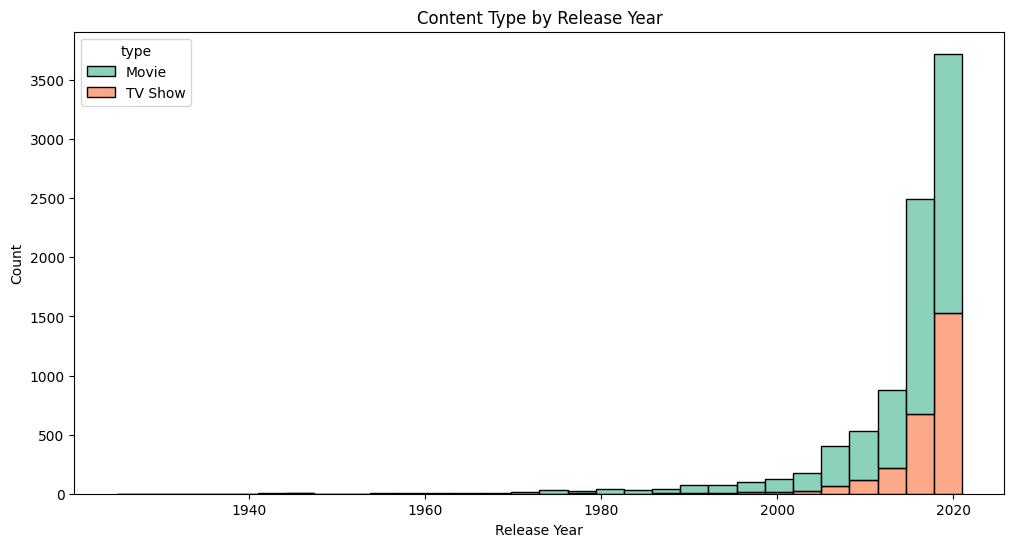

Descriptive Statistics for Release Year by Content Type:


,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Movie,6131.0,2013.121514,9.678169,1942.0,2012.0,2016.0,2018.0,2021.0
TV Show,2676.0,2016.605755,5.740138,1925.0,2016.0,2018.0,2020.0,2021.0


In [56]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='release_year', hue='type', multiple='stack', bins=30, palette='Set2')
plt.title('Content Type by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

print("Descriptive Statistics for Release Year by Content Type:")
display(df.groupby('type')['release_year'].describe())

### Country vs. Content Type

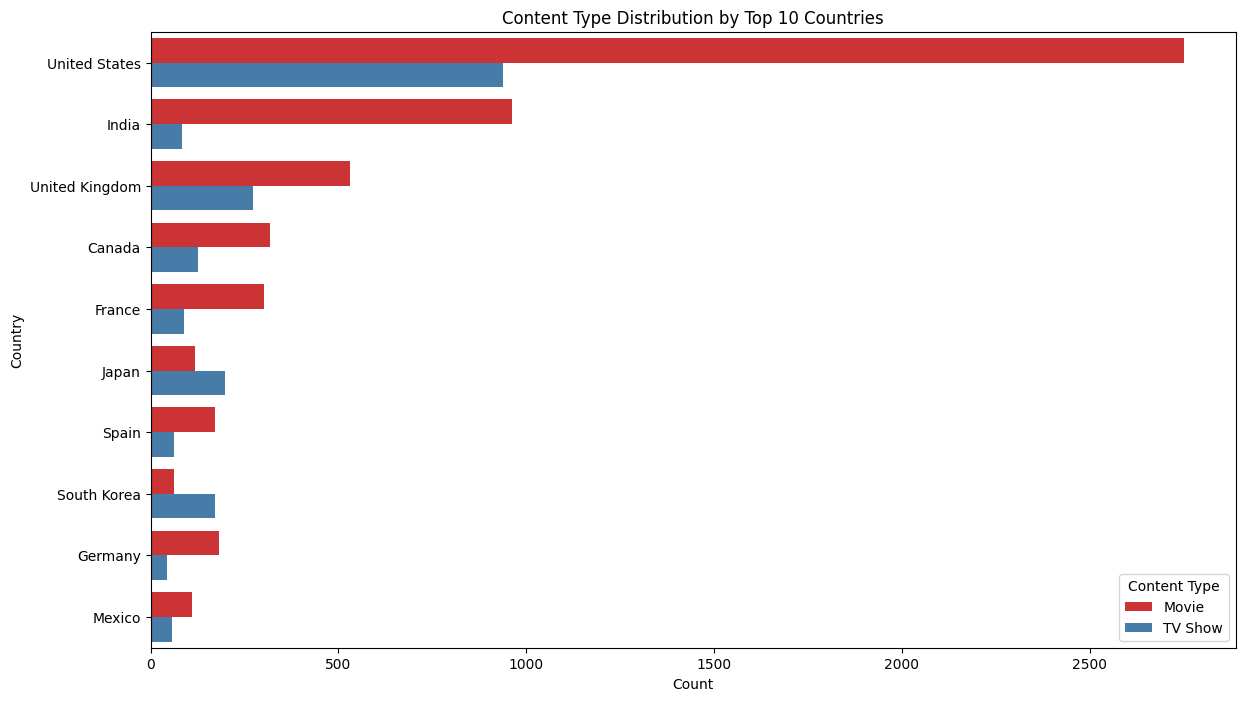

In [57]:
# creating  a melted DataFrame where each country has its own row per content item
countries_df = df.assign(country=df['country'].str.split(', ')).explode('country')

# Get the top N countries (excluding 'Unknown' for better visualization)
top_countries = countries_df['country'].value_counts().drop('Unknown', errors='ignore').head(10).index

# Filter the DataFrame to include only top countries
df_top_countries = countries_df[countries_df['country'].isin(top_countries)]

plt.figure(figsize=(14, 8))
sns.countplot(data=df_top_countries, y='country', hue='type', order=top_countries, palette='Set1')
plt.title('Content Type Distribution by Top 10 Countries')
plt.xlabel('Count')
plt.ylabel('Country')
plt.legend(title='Content Type')
plt.show()

In [58]:
print("Content Type Count by Top 10 Countries:")
display(df_top_countries.groupby('country')['type'].value_counts().unstack().fillna(0))

Content Type Count by Top 10 Countries:


type,Movie,TV Show
country,,
Canada,319,126
France,303,90
Germany,182,44
India,962,84
Japan,119,199
Mexico,111,58
South Korea,61,170
Spain,171,61
United Kingdom,532,272


### Content Type vs. Rating

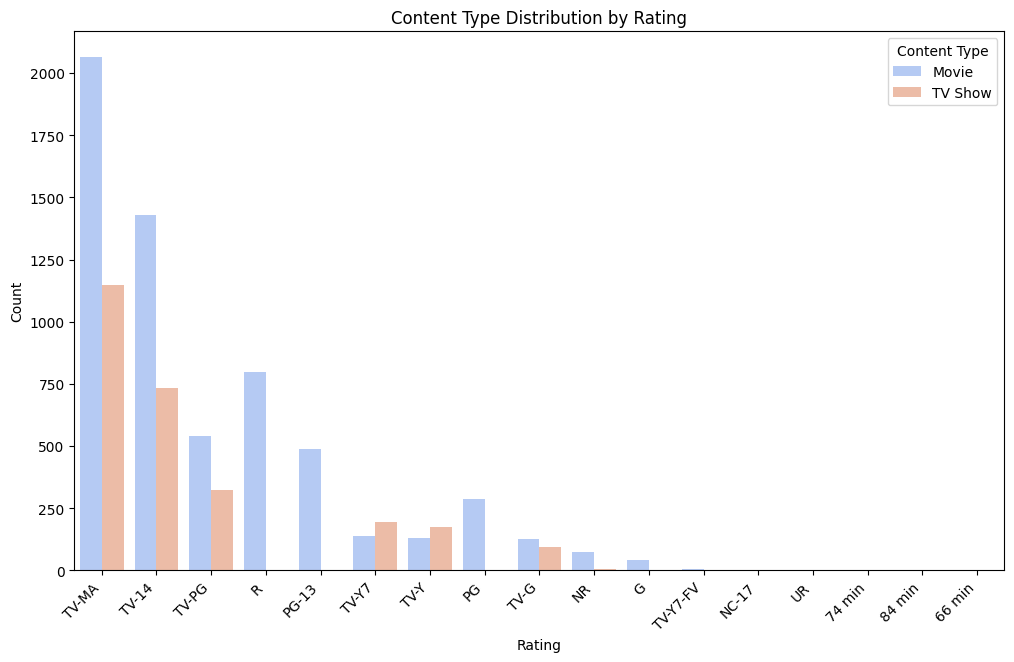

In [59]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='rating', hue='type', order=df['rating'].value_counts().index, palette='coolwarm')
plt.title('Content Type Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Content Type')
plt.show()

In [60]:
print("Content Type Count by Rating:")
display(df.groupby('rating')['type'].value_counts().unstack().fillna(0))

Content Type Count by Rating:


type,Movie,TV Show
rating,,
66 min,1.0,0.0
74 min,1.0,0.0
84 min,1.0,0.0
G,41.0,0.0
NC-17,3.0,0.0
NR,75.0,5.0
PG,287.0,0.0
PG-13,490.0,0.0
R,797.0,2.0


In [61]:
df['year_added'] = df['date_added'].dt.year
content_added_yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

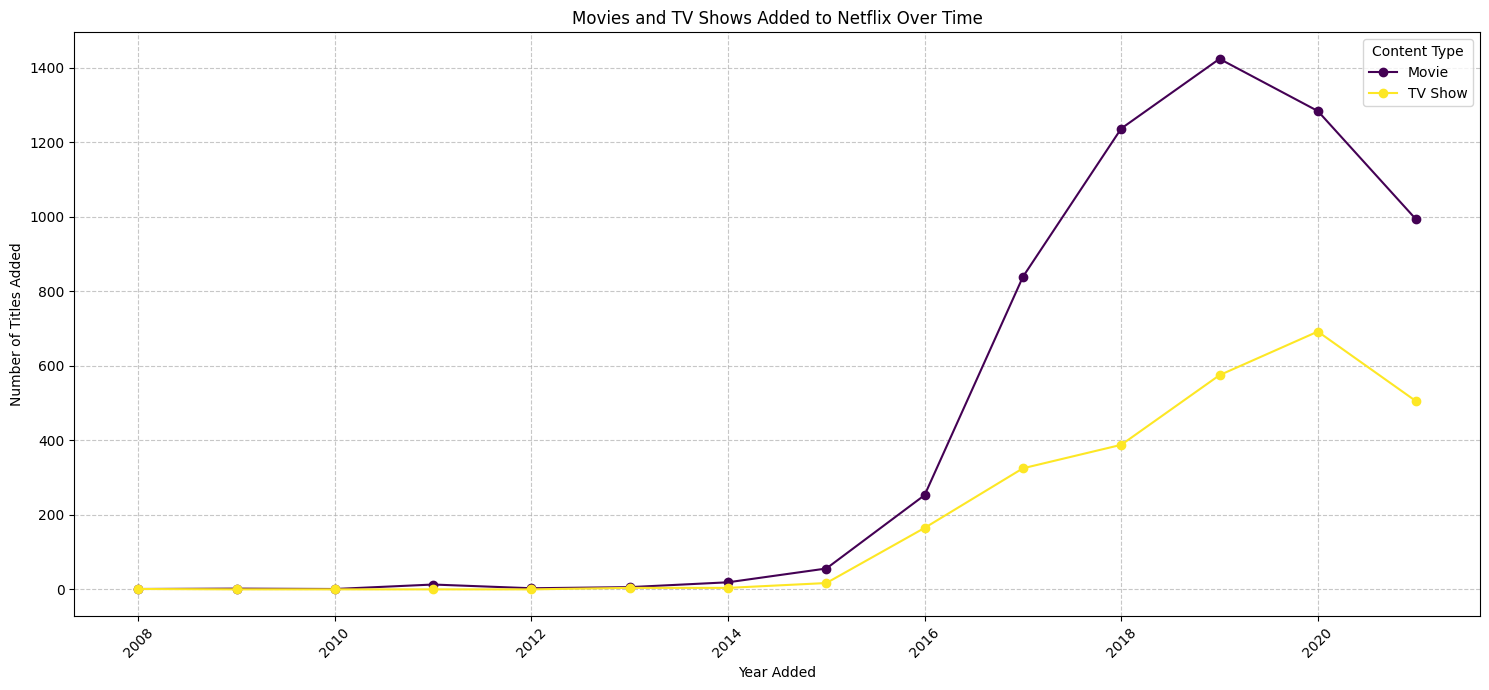

In [62]:
plt.figure(figsize=(15, 7))
content_added_yearly.plot(kind='line', marker='o', figsize=(15, 7), ax=plt.gca(), cmap='viridis')
plt.title('Movies and TV Shows Added to Netflix Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

In [63]:
print("Content Added Yearly by Type:")
display(content_added_yearly.tail())

Content Added Yearly by Type:


type,Movie,TV Show
year_added,,
2017,839,325
2018,1237,388
2019,1424,575
2020,1284,692
2021,993,505
